In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import geopandas as gpd
import rioxarray as rioxr
from shapely import box

import pystac_client
import planetary_computer

from IPython.display import Image



sys.path.append("../utils")

# import config

# pd.set_option("display.max_columns", None)


<Axes: >

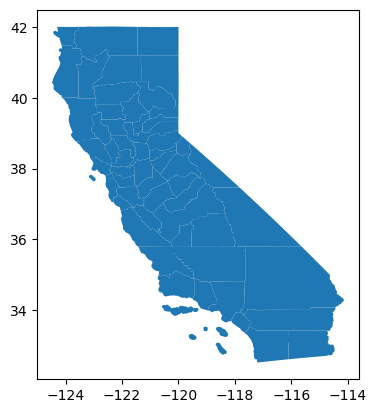

In [2]:
# Create bbox for Santa Barbara County

ca_counties = gpd.read_file("/capstone/wildfire_prep/data/ca_counties/CA_Counties.shp")

# MUST Use CRS 4326 to get land cover data from API. Equal Albers measures in Meters and not degrees lat long. 

CRS = "epsg:4326"

ca_counties = ca_counties.to_crs(CRS)

ca_counties.plot()


In [3]:
list(ca_counties.to_crs(ca_counties.crs).total_bounds)


[np.float64(-124.48201686112381),
 np.float64(32.528836736912375),
 np.float64(-114.13122247472313),
 np.float64(42.00950826992657)]

<Axes: >

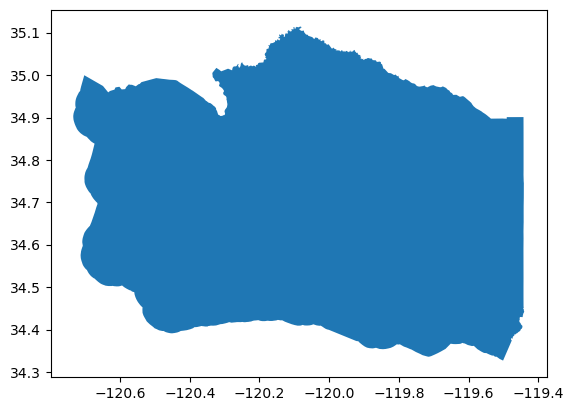

In [4]:
mp = ca_counties.loc[
    ca_counties["NAMELSAD"] == "Santa Barbara County", "geometry"
].iloc[0]

mainland_poly = max(list(mp.geoms), key=lambda p: p.area)

sb_county = gpd.GeoDataFrame(
    {"NAMELSAD": ["Santa Barbara County"], "geometry": [mainland_poly]},
    crs=ca_counties.crs,
)

sb_county.plot()

In [5]:
list(sb_county.to_crs(ca_counties.crs).total_bounds)


[np.float64(-120.73439466282672),
 np.float64(34.326926813516394),
 np.float64(-119.44039641801349),
 np.float64(35.11468285869654)]

In [6]:
sb_bbox = list(sb_county.to_crs(ca_counties.crs).total_bounds)

In [7]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

search = catalog.search(collections=["gap"], bbox=sb_bbox)
search


In [8]:
items = search.item_collection()
print(f"Returned {len(items)} Items")
items


Returned 1 Items


In [9]:
item = items[0]

# Display the pre-rendered image
Image(url=item.assets["rendered_preview"].href, width=600)


In [10]:
landcover = rioxr.open_rasterio(item.assets["data"].href)
landcover


<xarray.DataArray (band: 1, y: 10000, x: 10000)> Size: 200MB
[100000000 values with dtype=uint16]
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 80kB -2.361e+06 -2.361e+06 ... -2.061e+06
  * y            (y) float64 80kB 1.762e+06 1.762e+06 ... 1.462e+06 1.462e+06
    spatial_ref  int64 8B 0
Attributes:
    TIFFTAG_SOFTWARE:        ERDAS IMAGINE
    TIFFTAG_XRESOLUTION:     1
    TIFFTAG_YRESOLUTION:     1
    TIFFTAG_RESOLUTIONUNIT:  2 (pixels/inch)
    AREA_OR_POINT:           Area
    scale_factor:            1.0
    add_offset:              0.0

In [11]:
labels = pd.read_csv("landcover_data/GAP_National_Terrestrial_Ecosystems.csv")
labels = labels.drop(labels.index[0]).reset_index(drop=True)
labels.head()


,class_label,code
0,South Florida Bayhead Swamp,1
1,South Florida Cypress Dome,2
2,South Florida Dwarf Cypress Savanna,3
3,South Florida Mangrove Swamp,4
4,South Florida Hardwood Hammock,5


In [12]:
landcover = landcover.squeeze().drop_vars("band")

In [13]:
landcover_bbox = gpd.GeoDataFrame(
    geometry=[box(*landcover.rio.bounds())], crs=landcover.rio.crs
)
landcover_bbox


,geometry
0,"POLYGON ((-2061135 1462215, -2061135 1762215, ..."


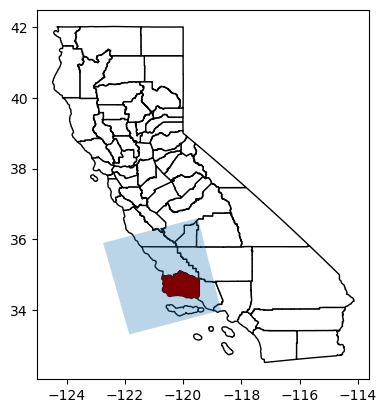

In [14]:
# Plot the raster boundary, ca boundary
fig, ax = plt.subplots()
ca_counties.plot(ax=ax, color="white", edgecolor="black")


landcover_bbox.to_crs(ca_counties.crs).plot(ax=ax, alpha=0.3)
sb_county.plot(ax=ax, color="maroon")

plt.show()


In [15]:
# variables:
# sb_bbox, bounding box for the county
# sb_county, shapefile for the county


# Match CRSs and verify update
sb_county_match = sb_county.to_crs(landcover.rio.crs)
assert sb_county_match.crs == landcover.rio.crs

In [16]:
landcover = landcover.rio.write_nodata(0)

landcover_clip = landcover.rio.clip_box(*sb_county_match.total_bounds).rio.clip(
    sb_county_match.geometry
)


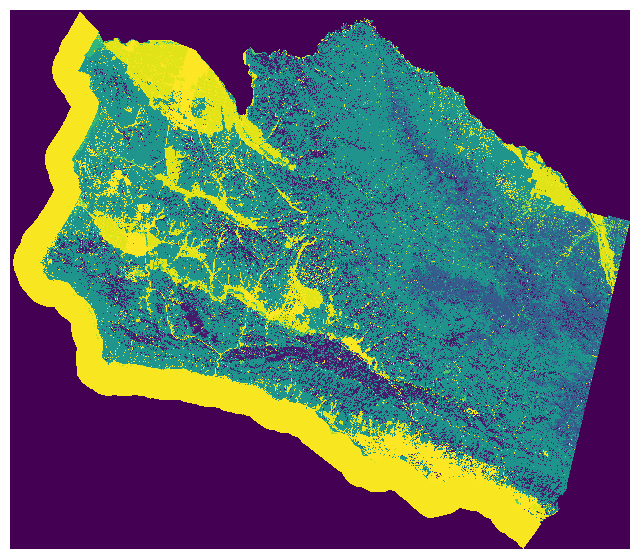

In [20]:
fig, ax = plt.subplots(figsize=(8, 7), facecolor="none")
ax.set_facecolor("none")

landcover_clip.plot(ax=ax, add_colorbar=False)

ax.set_title("")
ax.set_axis_off()

plt.savefig(
    "landcover_sb_transparent.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0,
)
plt.show()


Now time to load in buffered geometries and find the landcover for each.


In [64]:
# Loading in inspections data with newly calculated geometries 4/28/25

inspections = gpd.read_file(
    "/capstone/wildfire_prep/data/PUZZLE_PIECES/inspections_master.geojson"
)

inspections = inspections.to_crs(landcover.rio.crs)
assert inspections.crs == landcover.rio.crs

In [65]:
inspections


,inspection_id,status,year,month,Date,a_removebr,a_removebranchesfromstovepipe,accessegre,accessegress,address__1,...,water_comm,water_comments,water_sour,water_source,water_stor,water_storage_size_stored_water_on_individual_parcels_only,waterstora,windowpane,yearbuilt,geometry
0,1,Compliant,2019,6,2019-06-05,None,None,yes,None,None,...,None,None,Private Hydrant- Private Stored Water,None,Over 5000 gallons,None,yes,No Windows,2000.0,"POLYGON ((-2161320.551 1564613.927, -2161341.6..."
1,2,Compliant,2019,5,2019-05-09,None,None,yes,None,None,...,None,None,Private Hydrant- Private Stored Water,None,None,None,yes,Single Pane,0.0,"POLYGON ((-2166416.735 1566929.327, -2166519.5..."
2,3,Compliant,2019,5,2019-05-09,None,None,yes,None,None,...,None,None,None,None,None,None,None,Multi Pane,0.0,"POLYGON ((-2166360.165 1566692.606, -2166247.2..."
3,4,Compliant,2019,5,2019-05-09,None,None,yes,None,None,...,None,None,None,None,None,None,no,Single Pane,0.0,"POLYGON ((-2166289.215 1566761.998, -2166271.7..."
4,5,Compliant,2019,12,2019-12-17,None,None,yes,None,None,...,None,None,Pond,None,None,None,yes,Single Pane,2002.0,"POLYGON ((-2166019.677 1566870.269, -2166048.1..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67575,67576,Compliant,2023,10,2023-10-31,None,None,None,Yes,None,...,None,None,None,None,None,None,None,None,NaN,"POLYGON ((-2186564.285 1594378.626, -2186615.5..."
67576,67577,Compliant,2023,11,2023-11-15,None,None,None,Yes,None,...,None,None,None,None,None,None,None,None,NaN,"POLYGON ((-2188291.143 1593936.549, -2188270.0..."
67577,67578,Compliant,2023,11,2023-11-15,None,None,None,Yes,None,...,None,None,None,None,None,None,None,None,NaN,"POLYGON ((-2189313.201 1598676.653, -2189332.5..."
67578,67579,Compliant,2023,11,2023-11-15,None,None,None,Yes,None,...,None,None,None,None,None,None,None,None,NaN,"POLYGON ((-2189596.026 1598715.491, -2189496.3..."


In [66]:
# Drop all columns except inspection_id and geometry

inspections = inspections[
    ["inspection_id", "geometry"]
].copy()

In [67]:
inspections.head()

,inspection_id,geometry
0,1,"POLYGON ((-2161320.551 1564613.927, -2161341.6..."
1,2,"POLYGON ((-2166416.735 1566929.327, -2166519.5..."
2,3,"POLYGON ((-2166360.165 1566692.606, -2166247.2..."
3,4,"POLYGON ((-2166289.215 1566761.998, -2166271.7..."
4,5,"POLYGON ((-2166019.677 1566870.269, -2166048.1..."


In [68]:
inspections.crs

<Projected CRS: EPSG:5070>
Name: NAD83 / Conus Albers
Axis Info [cartesian]:
- [east]: Easting (metre)
- [north]: Northing (metre)
Area of Use:
- undefined
Coordinate Operation:
- name: unnamed
- method: Albers Equal Area
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [69]:
# single row dataframe, a random sample from inspections, for testing

single_row = inspections[
    inspections.groupby("inspection_id")["inspection_id"].transform(
        "size"
    )
    == 1
].sample(n=1)


In [70]:
# code from EDS220 homework

landcover_clip = landcover.rio.clip_box(*single_row.total_bounds).rio.clip(
    single_row.geometry
)

# Count unqiue values in landcover_clip
values, counts = np.unique(landcover_clip, return_counts=True)

# Add counts to new dataframe `pix_counts`
pix_counts = pd.DataFrame({"code": values, "count": counts})

# Merge `pix_counts` with `labels` dataframe
classes = pix_counts[pix_counts["code"] != 0].merge(labels, on="code")


In [71]:
classes

,code,count,class_label
0,557,1,Pasture/Hay


In [72]:
from rioxarray.exceptions import NoDataInBounds, OneDimensionalRaster

def compute_landcover_maj(
    data, id_col="inspection_id", landcover=landcover, labels=labels
):
    """
    For each row in `data` (each has its own inspection_id), clip the `landcover` raster
    to that row’s geometry, count pixel codes (excluding 0), join to labels,
    pick the majority code, and put it into 'maj_landcover_code'.

    I encountered some errors when working with the full dataset, so there are some exceptions:

    - NoDataInBounds -> NaN
    - OneDimensionalRaster -> retry bbox-only clip with allow_one_dimensional_raster
    """
    maj_codes = []

    # each row, no grouping
    for _, row in data.iterrows():
        addr = row[id_col]
        geom = row.geometry
        minx, miny, maxx, maxy = geom.bounds

        try:
            clipped = landcover.rio.clip_box(minx, miny, maxx, maxy).rio.clip([geom])

        except NoDataInBounds:
            maj_codes.append(np.nan)
            continue

        except OneDimensionalRaster:
            # tiny slice: allow one‐dim on the bbox step, skip the geometry mask
            clipped = landcover.rio.clip_box(
                minx, miny, maxx, maxy, allow_one_dimensional_raster=True
            )

        # count codes
        vals, counts = np.unique(clipped.values, return_counts=True)
        pix_counts = (
            pd.DataFrame({"code": vals, "count": counts})
            .query("code != 0")
            .merge(labels, on="code", how="left")
        )

        if pix_counts.empty:
            maj_codes.append(np.nan)
        else:
            maj_codes.append(pix_counts.loc[pix_counts["count"].idxmax(), "code"])

    out = data.copy()
    out["maj_landcover_code"] = maj_codes
    return out

compute_landcover_maj(single_row)


,inspection_id,geometry,maj_landcover_code
4888,4889,"POLYGON ((-2107672.887 1569394.42, -2107661.34...",557


In [ ]:
inspections = compute_landcover_maj(inspections)


In [ ]:
# landcover codes are coming in with the format '582.0', so let's make them integers
inspections["maj_landcover_code"] = inspections["maj_landcover_code"].astype("Int64")


In [ ]:
print(inspections.columns.tolist())
inspections = inspections.rename(
    columns={"maj_landcover_code": "buffgeo_landcover_code"}
)
print(inspections.columns.tolist())


In [ ]:
print(inspections["buffgeo_landcover_code"].value_counts(dropna=False))
print(inspections.shape)

In [ ]:
inspections = inspections[["inspection_id", "buffgeo_landcover_code"]]

inspections

In [ ]:
# inspections.to_csv(
#     "/capstone/wildfire_prep/data/PUZZLE_PIECES/inspection_id_landcover_buffer_geometries.csv",
#     index=False,



In [ ]:
landcover_codes = inspections['buffgeo_landcover_code'].rename('code').to_frame()
landcover_codes = landcover_codes.merge(labels, on="code", how="left")
landcover_codes = landcover_codes.drop_duplicates().sort_values(by='code').reset_index(drop=True)
landcover_codes

In [ ]:
# landcover_codes.to_csv(
#     "/capstone/wildfire_prep/data/metadata/landcover_codes.csv",
#     index=False,

